### Load Dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.preprocessing import LabelEncoder

sns.set(style='whitegrid')

df = pd.read_csv('cleaned_cafe_sales.csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8613 entries, 0 to 8612
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    8613 non-null   object 
 1   Item              8613 non-null   object 
 2   Quantity          8613 non-null   float64
 3   Price Per Unit    8613 non-null   float64
 4   Total Spent       8613 non-null   float64
 5   Payment Method    8613 non-null   object 
 6   Transaction Date  8613 non-null   object 
dtypes: float64(3), object(4)
memory usage: 471.2+ KB


In [24]:
# Pastikan kolom tanggal bertipe datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Ekstrak fitur waktu dari Transaction Date
df['Month']      = df['Transaction Date'].dt.month
df['DayOfWeek']  = df['Transaction Date'].dt.dayofweek
df['DayOfMonth'] = df['Transaction Date'].dt.day
df['Hour']       = df['Transaction Date'].dt.hour

In [25]:
# Label Encoding untuk kolom kategorikal
le  =LabelEncoder()

df['Item_encoded']           = le.fit_transform(df['Item'])
df['PaymentMethod_encoded'] = le.fit_transform(df['Payment Method'])


print('Kolom setelah feature enginering')
print(df.columns.tolist())
df.head()

Kolom setelah feature enginering
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Transaction Date', 'Month', 'DayOfWeek', 'DayOfMonth', 'Hour', 'Item_encoded', 'PaymentMethod_encoded']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Month,DayOfWeek,DayOfMonth,Hour,Item_encoded,PaymentMethod_encoded
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01,1,6,1,0,2,1
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01,1,6,1,0,3,2
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01,1,6,1,0,5,2
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01,1,6,1,0,4,3
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01,1,6,1,0,5,0


## Feature Selection - 

In [26]:
# Pilih kolom numerik yang akan dianalisi
numeric_feature = [
    'Quantity', 'Price Per Unit', 'Total Spent',
    'Month', 'DayOfWeek', 'DayOfMonth',
    'Item_encoded', 'PaymentMethod_encoded'
]

df_numeric = df[numeric_feature]

# Hitung Correlaction Matrix
corr_matrix = df_numeric.corr(method='pearson')

print('Pearson Correlation Matrix:')
corr_matrix.round(3)

Pearson Correlation Matrix:


,Quantity,Price Per Unit,Total Spent,Month,DayOfWeek,DayOfMonth,Item_encoded,PaymentMethod_encoded
Quantity,1.000,0.002,0.706,-0.004,0.001,-0.007,0.006,-0.006
Price Per Unit,0.002,1.000,0.644,-0.013,-0.001,0.021,0.228,-0.023
Total Spent,0.706,0.644,1.000,-0.006,0.004,0.005,0.152,-0.019
Month,-0.004,-0.013,-0.006,1.000,0.018,0.001,-0.007,-0.011
DayOfWeek,0.001,-0.001,0.004,0.018,1.000,-0.008,-0.009,0.001
DayOfMonth,-0.007,0.021,0.005,0.001,-0.008,1.000,0.015,-0.005
Item_encoded,0.006,0.228,0.152,-0.007,-0.009,0.015,1.000,0.002
PaymentMethod_encoded,-0.006,-0.023,-0.019,-0.011,0.001,-0.005,0.002,1.000


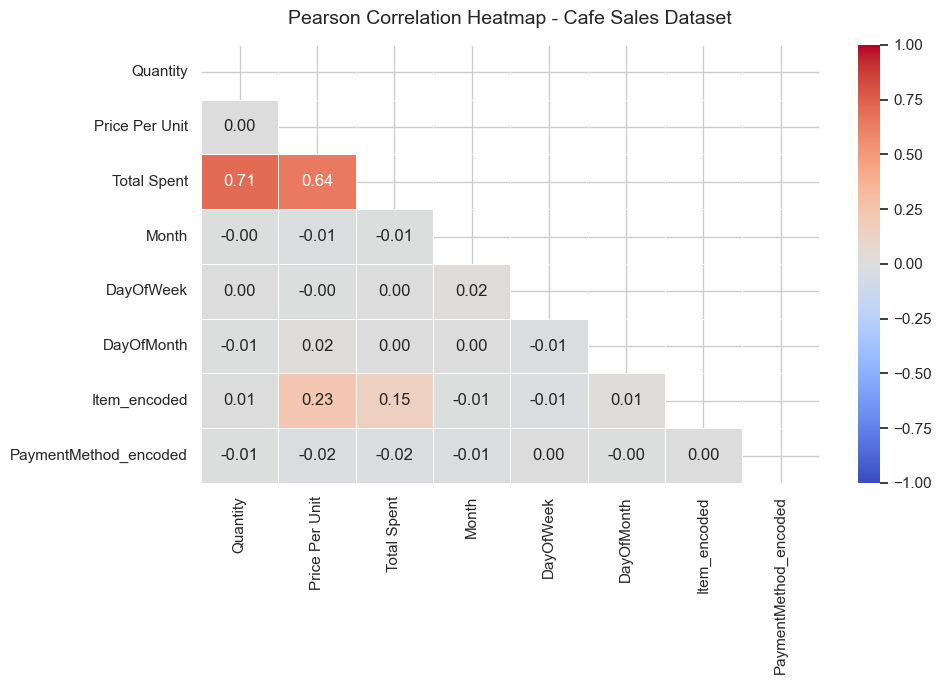

In [27]:
# Visualisasi Heatmap
plt.figure(figsize=(10,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap= 'coolwarm',
    center=0,
    mask=mask,
    linewidth=0.5,
    vmin=-1, vmax=1
)

plt.title('Pearson Correlation Heatmap - Cafe Sales Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [28]:
# Korelasi Setiap Feaeture Terhadap Target (Total Spent)
target = 'Total Spent'
corr_with_target = (
    df_numeric.corr(method='pearson')[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

print('Korelasi fitur dengan target (Total Spent):')
print(corr_with_target.to_string())

Korelasi fitur dengan target (Total Spent):
Quantity                 0.705991
Price Per Unit           0.644480
Item_encoded             0.151638
PaymentMethod_encoded   -0.019353
Month                   -0.005859
DayOfMonth               0.004627
DayOfWeek                0.004408


In [29]:
# Seleksi Fitur Berdasarkan Threesold Korelasi
THRESHOLD = 0.1 # Fitur dengan |Korelasi| >= threshold dianggap relevan

selected_by_pearson = corr_with_target[abs(corr_with_target) >= THRESHOLD].index.to_list()
dropped_by_pearson = corr_with_target[abs(corr_with_target) < THRESHOLD].index.to_list()

print(f'Threshold korelasi : |r| >= {THRESHOLD}')
print(f'Fitur DIPILIH ({len(selected_by_pearson)}): {selected_by_pearson}')
print(f'Fitur DIBUANG ({len(dropped_by_pearson)}): {dropped_by_pearson}')

Threshold korelasi : |r| >= 0.1
Fitur DIPILIH (3): ['Quantity', 'Price Per Unit', 'Item_encoded']
Fitur DIBUANG (4): ['PaymentMethod_encoded', 'Month', 'DayOfMonth', 'DayOfWeek']


In [30]:
X = df_numeric.drop(['Total Spent'], axis=1)
y = df_numeric['Total Spent']

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (8613, 7)
Shape y: (8613,)


In [47]:
# Hitung F-score dan p-value untuk SEMUA fitur
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(X, y)

# Buat DataFrame ringkasan
skb_results = pd.DataFrame({
    'Fitur': X.columns,
    'F-Score': selector_all.scores_,
    'P-Value': selector_all.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

# Tandai signifikansi (p-value < 0.05)
skb_results['Signifikan'] = skb_results['P-Value'].apply(lambda p: 'Ya' if p < 0.05 else 'Tidak')

print('Skor SelectKBest (f_regression) - semua fitur:')
skb_results.round(4)

Skor SelectKBest (f_regression) - semua fitur:


,Fitur,F-Score,P-Value,Signifikan
0,Quantity,8556.8652,0.0000,Ya
1,Price Per Unit,6117.5863,0.0000,Ya
2,Item_encoded,202.6626,0.0000,Ya
3,PaymentMethod_encoded,3.2265,0.0725,Tidak
4,Month,0.2956,0.5867,Tidak
5,DayOfMonth,0.1844,0.6677,Tidak
6,DayOfWeek,0.1673,0.6825,Tidak


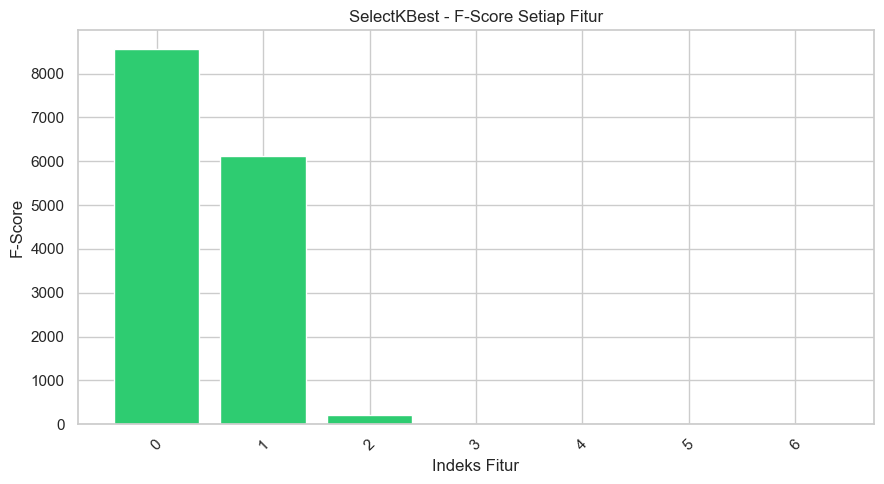

In [48]:
# Visualisasi F-Score
plt.figure(figsize=(9, 5))
bar_colors = ['#2ecc71' if p < 0.05 else '#e74c3c' 
              for p in skb_results['P-Value']]

plt.bar(skb_results.index, skb_results['F-Score'], color=bar_colors)
plt.title('SelectKBest - F-Score Setiap Fitur')
plt.xlabel('Indeks Fitur')
plt.ylabel('F-Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SelectKBest - F-Score Setiap Fitur
# (Hijau = signifikan p<0.05, Merah = tidak signifikan)

In [49]:
# Get the names of the selected features
selected_features = X.columns[selector_all.get_support()]

# Transform the original feature matrix X to get the selected features
X_selected = selector_all.transform(X)

X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df['Total Spent'] = y.values  # Tambahkan kolom target

print("Dataset setelah SelectKBest:")
X_selected_df.head(10)

Dataset setelah SelectKBest:


,Quantity,Price Per Unit,Month,DayOfWeek,DayOfMonth,Item_encoded,PaymentMethod_encoded,Total Spent
0,4.000000,1.000000,1.0,6.0,1.0,2.0,1.0,4.000000
1,1.000000,3.000000,1.0,6.0,1.0,3.0,2.0,3.000000
2,5.000000,2.951766,1.0,6.0,1.0,5.0,2.0,14.758828
3,3.029846,5.000000,1.0,6.0,1.0,4.0,3.0,15.149228
4,5.000000,4.000000,1.0,6.0,1.0,5.0,0.0,20.000000
5,2.000000,2.000000,1.0,6.0,1.0,1.0,0.0,4.000000
6,4.000000,3.000000,1.0,6.0,1.0,0.0,0.0,12.000000
7,2.000000,4.000000,1.0,6.0,1.0,6.0,2.0,8.000000
8,4.000000,2.000000,1.0,6.0,1.0,1.0,2.0,8.000000
9,5.000000,1.500000,1.0,6.0,1.0,7.0,3.0,7.500000


## E. Perbandingan Hasil: Person Correlaction vs SelectKBest

In [51]:
# Tabel Pertandingan
comparison = pd.DataFrame({
    'Fitur': X.columns,
    'Pearson r': [round(abs(corr_with_target.get(f, 0)), 4) for f in X.columns],
    'Pearson Dipilih': ['dipilih' if f in selected_by_pearson else 'tidak dipilih' for f in X.columns],
    'SKB F-Score': [round(selector_all.scores_[i], 2) for i, f in enumerate(X.columns)],
    'SKB P-Value': [round(selector_all.pvalues_[i], 4) for i, f in enumerate(X.columns)],
    'SKB Top-4': ['dipilih' if f in selected_features else 'tidak dipilih' for f in X.columns],
}).sort_values('SKB F-Score', ascending=False)

print('Perbandingan Pearson Correlation vs SelectKBest:')
comparison

Perbandingan Pearson Correlation vs SelectKBest:


,Fitur,Pearson r,Pearson Dipilih,SKB F-Score,SKB P-Value,SKB Top-4
0,Quantity,0.7060,dipilih,8556.87,0.0000,dipilih
1,Price Per Unit,0.6445,dipilih,6117.59,0.0000,dipilih
5,Item_encoded,0.1516,dipilih,202.66,0.0000,dipilih
6,PaymentMethod_encoded,0.0194,tidak dipilih,3.23,0.0725,dipilih
2,Month,0.0059,tidak dipilih,0.30,0.5867,dipilih
4,DayOfMonth,0.0046,tidak dipilih,0.18,0.6677,dipilih
3,DayOfWeek,0.0044,tidak dipilih,0.17,0.6825,dipilih


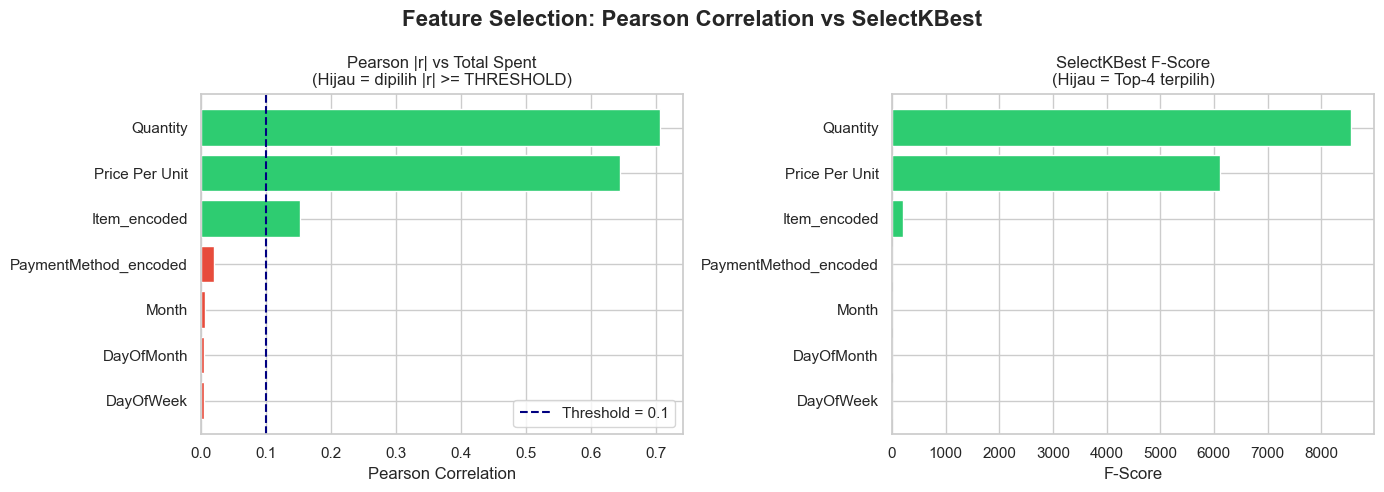

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Selection: Pearson Correlation vs SelectKBest', fontsize=16, fontweight='bold')

# Plot 1: Pearson
pearson_sorted = corr_with_target.reindex(X.columns).abs().sort_values(ascending=True)
colors_p = ['#2ecc71' if v > THRESHOLD else '#e74c3c' for v in pearson_sorted.values]
axes[0].barh(pearson_sorted.index, pearson_sorted.values, color=colors_p)
axes[0].axvline(THRESHOLD, color='navy', linestyle='--', label=f'Threshold = {THRESHOLD}')
axes[0].set_title(f'Pearson |r| vs Total Spent\n(Hijau = dipilih |r| >= THRESHOLD)')
axes[0].set_xlabel('Pearson Correlation')
axes[0].legend()

# Plot 2: SelectKBest
skb_sorted = skb_results.sort_values('F-Score', ascending=True)
colors_s = ['#2ecc71' if f in selected_features else '#e74c3c' 
            for f in skb_sorted['Fitur']]
axes[1].barh(skb_sorted['Fitur'], skb_sorted['F-Score'], color=colors_s)
axes[1].set_title(f'SelectKBest F-Score\n(Hijau = Top-4 terpilih)')
axes[1].set_xlabel('F-Score')

plt.tight_layout()
plt.show()

## G. Simpan Dataset Dengan Fitur Terpilih

In [53]:
# Simpan dataset yang sudah melalui feature selection
X_selected_df.to_csv("featured_cafe_sales.csv", index=False)

print("Dataset tersimpan sebagai: featured_cafe_sales.csv")
print(f"    Fitur yang tersimpan : {X_selected_df.columns.tolist()}")
print(f"    Jumlah baris    : {len(X_selected_df)}")

Dataset tersimpan sebagai: featured_cafe_sales.csv
    Fitur yang tersimpan : ['Quantity', 'Price Per Unit', 'Month', 'DayOfWeek', 'DayOfMonth', 'Item_encoded', 'PaymentMethod_encoded', 'Total Spent']
    Jumlah baris    : 8613
